## Practico Aprendizaje No Supervisado

### Importar librerias

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

sns.set_theme(style="whitegrid")

### Cargar datos

In [3]:
male_players = pd.read_csv("../Data/male_players.csv")

C:\Users\Usuario\AppData\Local\Temp\ipykernel_20436\4161528585.py:1: DtypeWarning: Columns (108) have mixed types. Specify dtype option on import or set low_memory=False.
  male_players = pd.read_csv("../Data/male_players.csv")


### Estructura del dataset y tipos de variables

El dataset analizado contiene *'180.021 filas'* y *'109 columnas'*

In [4]:
print("Dimensiones del dataset: ", male_players.shape)
print(male_players.info())

Dimensiones del dataset:  (180021, 109)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180021 entries, 0 to 180020
Columns: 109 entries, player_id to gk
dtypes: float64(20), int64(43), object(46)
memory usage: 149.7+ MB
None


### Limpieza de datos

Hacemos una copia del dataset original para no modificar el dataset original.

Notamos que las columnas con atributos de jugadores como 'ls', 'st', 'rs', son variables de tipo string, cuando en realidad deberian ser numericas, hay valores que son por ejemplo **90+3**. Procedemos a limpiar estas 27 variables y asignarle su verdadero data type.

### Deduplicación: quedarnos con la versión más reciente de cada jugador

Antes de limpiar columnas, hay un problema más importante en las filas: el dataset tiene **180.021 filas pero solo 53.111 `player_id` únicos**. Esto es porque el CSV original incluye el historial completo de versiones del videojuego (FIFA 15 a EA Sports FC 24) — cada jugador aparece repetido una vez por cada versión en la que fue incluido (`fifa_version` de 15.0 a 24.0).

Para nuestro objetivo (encontrar grupos de jugadores *actuales* con habilidades equivalentes, pensando en reemplazos dentro de un plantel real) esto es un problema serio si no lo corregimos: clusterizar sobre las 180.021 filas significa clusterizar con el mismo jugador repetido en promedio ~3.4 veces (con atributos casi idénticos entre una versión y la siguiente), lo que **infla artificialmente el tamaño de los clusters y distorsiona las métricas de evaluación** (de hecho, fue justamente al intentar calcular el silhouette sobre las ~160.000 filas de campo, sin deduplicar, que el cálculo se volvió tan pesado que la celda de abajo se quedó colgada y tuvimos que interrumpirla).

La solución es quedarnos con una sola fila por jugador: la versión más reciente, `fifa_version == 24`.

In [5]:
print('Filas antes de deduplicar:', male_players.shape[0], '| player_id únicos:', male_players['player_id'].nunique())
print(male_players['fifa_version'].value_counts().sort_index())

male_players = male_players[male_players['fifa_version'] == 24].copy()

print('\nFilas después de quedarnos con fifa_version == 24:', male_players.shape[0])
print('Duplicados de player_id restantes:', male_players['player_id'].duplicated().sum())

Filas antes de deduplicar: 180021 | player_id únicos: 53111
fifa_version
15.0    16182
16.0    16706
17.0    17596
18.0    17954
19.0    18086
20.0    18483
21.0    18892
22.0    19239
23.0    18533
24.0    18350
Name: count, dtype: int64

Filas después de quedarnos con fifa_version == 24: 18350
Duplicados de player_id restantes: 0


In [6]:
# crear la copia ANTES de tocar nada
male_players_limpio = male_players.copy()

# 1. Detectar columnas afectadas (sobre la copia)
afectadas = [c for c in male_players_limpio.columns
             if male_players_limpio[c].astype(str).str.replace(" ", "", regex=False)
                                                   .str.match(r'^\d+[+-]\d+$').any()]
print("Columnas a convertir:", afectadas)
print("Cantidad de columnas a convertir:", len(afectadas))

Columnas a convertir: ['ls', 'st', 'rs', 'lw', 'lf', 'cf', 'rf', 'rw', 'lam', 'cam', 'ram', 'lm', 'lcm', 'cm', 'rcm', 'rm', 'lwb', 'ldm', 'cdm', 'rdm', 'rwb', 'lb', 'lcb', 'cb', 'rcb', 'rb', 'gk']
Cantidad de columnas a convertir: 27


In [7]:
def parse_rating(valor):
    """'90+3' -> 93, '85-2' -> 83, '90' -> 90. Nulo o no parseable -> NaN."""
    if pd.isna(valor):
        return np.nan
    s = str(valor).replace(" ", "")           # limpio espacios tipo "90 + 3"
    m = re.fullmatch(r'(\d+)([+-]\d+)?', s)   # base + modificador opcional
    if m is None:
        return np.nan
    base = int(m.group(1))
    return base + int(m.group(2)) if m.group(2) else base

In [8]:
# 2. Chequeo de seguridad
for c in afectadas:
    no_nulos_antes = male_players_limpio[c].notna().sum()
    parseables     = male_players_limpio[c].map(parse_rating).notna().sum()
    perdidos = no_nulos_antes - parseables
    if perdidos > 0:
        print(f"  ⚠ {c}: {perdidos} valores no parseables (revisar antes de seguir)")
    else:
        print(f"  ✓ {c}: OK")

  ✓ ls: OK
  ✓ st: OK
  ✓ rs: OK
  ✓ lw: OK
  ✓ lf: OK
  ✓ cf: OK
  ✓ rf: OK
  ✓ rw: OK
  ✓ lam: OK
  ✓ cam: OK
  ✓ ram: OK
  ✓ lm: OK
  ✓ lcm: OK
  ✓ cm: OK
  ✓ rcm: OK
  ✓ rm: OK
  ✓ lwb: OK
  ✓ ldm: OK
  ✓ cdm: OK
  ✓ rdm: OK
  ✓ rwb: OK
  ✓ lb: OK
  ✓ lcb: OK
  ✓ cb: OK
  ✓ rcb: OK
  ✓ rb: OK
  ✓ gk: OK


In [9]:
# 3. Aplicar la conversión SOBRE LA COPIA
for c in afectadas:
    male_players_limpio[c] = pd.to_numeric(male_players_limpio[c].map(parse_rating)).astype("Int64")

# 4. Verificar
print(male_players_limpio[afectadas].dtypes)
male_players_limpio[afectadas].head()

ls     Int64
st     Int64
rs     Int64
lw     Int64
lf     Int64
cf     Int64
rf     Int64
rw     Int64
lam    Int64
cam    Int64
ram    Int64
lm     Int64
lcm    Int64
cm     Int64
rcm    Int64
rm     Int64
lwb    Int64
ldm    Int64
cdm    Int64
rdm    Int64
rwb    Int64
lb     Int64
lcb    Int64
cb     Int64
rcb    Int64
rb     Int64
gk     Int64
dtype: object


,ls,st,rs,lw,lf,cf,rf,rw,lam,cam,...,ldm,cdm,rdm,rwb,lb,lcb,cb,rcb,rb,gk
0,93,93,93,91,91,91,91,91,92,92,...,66,66,66,71,66,57,57,57,66,21
1,93,93,93,82,86,86,86,82,85,85,...,66,66,66,65,63,65,65,65,63,22
2,86,86,86,87,88,88,88,87,91,91,...,83,83,83,82,78,73,73,73,78,24
3,88,88,88,90,89,89,89,90,90,90,...,66,66,66,67,62,52,52,52,62,22
4,90,90,90,86,89,89,89,86,90,90,...,67,67,67,67,63,58,58,58,63,21


In [10]:
male_players_limpio.head()

,player_id,player_url,fifa_version,fifa_update,update_as_of,short_name,long_name,player_positions,overall,potential,...,ldm,cdm,rdm,rwb,lb,lcb,cb,rcb,rb,gk
0,231747,/player/231747/kylian-mbappe/240002,24.0,2.0,2023-09-22,K. Mbappé,Kylian Mbappé Lottin,"ST, LW",91,94,...,66,66,66,71,66,57,57,57,66,21
1,239085,/player/239085/erling-haaland/240002,24.0,2.0,2023-09-22,E. Haaland,Erling Braut Haaland,ST,91,94,...,66,66,66,65,63,65,65,65,63,22
2,192985,/player/192985/kevin-de-bruyne/240002,24.0,2.0,2023-09-22,K. De Bruyne,Kevin De Bruyne,"CM, CAM",91,91,...,83,83,83,82,78,73,73,73,78,24
3,158023,/player/158023/lionel-messi/240002,24.0,2.0,2023-09-22,L. Messi,Lionel Andrés Messi Cuccittini,"CF, CAM",90,90,...,66,66,66,67,62,52,52,52,62,22
4,165153,/player/165153/karim-benzema/240002,24.0,2.0,2023-09-22,K. Benzema,Karim Benzema,"CF, ST",90,90,...,67,67,67,67,63,58,58,58,63,21


### Tipos de variables

Antes de trabajar con las variables conviene entender qué tenemos. Con 109 columnas,
clasificarlas primero nos permite decidir con criterio cuáles usar y cuáles descartar,
en lugar de mirarlas de a una.

Aplicamos **dos clasificaciones complementarias**:

- **Clasificación analítica** — agrupa las columnas según su tipo de dato: *numéricas*,
  *categóricas* e *identificadores*. Responde a la pregunta técnica de *cómo* está
  representada cada variable.

- **Clasificación de dominio** — agrupa las columnas según *qué representan* sobre el
  jugador (datos físicos, habilidades, valor de mercado, etc.). Responde a la pregunta
  conceptual de *qué significa* cada variable y nos ayuda a elegir cuáles alimentan
  el análisis.

A continuación listamos todas las columnas del dataset y luego las clasificamos con
ambos enfoques.

In [11]:
pd.set_option("display.max_seq_items", None)   # None = sin límite
male_players_limpio.columns

Index(['player_id', 'player_url', 'fifa_version', 'fifa_update',
       'update_as_of', 'short_name', 'long_name', 'player_positions',
       'overall', 'potential', 'value_eur', 'wage_eur', 'age', 'dob',
       'height_cm', 'weight_kg', 'club_team_id', 'club_name', 'league_id',
       'league_name', 'league_level', 'club_position', 'club_jersey_number',
       'club_loaned_from', 'club_joined_date',
       'club_contract_valid_until_year', 'nationality_id', 'nationality_name',
       'nation_team_id', 'nation_position', 'nation_jersey_number',
       'preferred_foot', 'weak_foot', 'skill_moves',
       'international_reputation', 'work_rate', 'body_type', 'real_face',
       'release_clause_eur', 'player_tags', 'player_traits', 'pace',
       'shooting', 'passing', 'dribbling', 'defending', 'physic',
       'attacking_crossing', 'attacking_finishing',
       'attacking_heading_accuracy', 'attacking_short_passing',
       'attacking_volleys', 'skill_dribbling', 'skill_curve',
       's

In [12]:
def clasificar_por_tipo(df, umbral_id=0.9):
    clasif = {"identificadores": [], "numericas": [], "categoricas": []}
    n = len(df)
    for col in df.columns:
        nombre = col.lower()
        card = df[col].nunique(dropna=True) / n
        es_id_por_nombre = nombre.endswith("_id") or "url" in nombre or nombre == "player_id"

        if es_id_por_nombre or card > umbral_id:
            clasif["identificadores"].append(col)
        elif pd.api.types.is_numeric_dtype(df[col]):
            clasif["numericas"].append(col)
        else:
            clasif["categoricas"].append(col)
    return clasif

tipos = clasificar_por_tipo(male_players_limpio)
for k, v in tipos.items():
    print(f"\n{k.upper()} ({len(v)}):\n{v}")


IDENTIFICADORES (8):
['player_id', 'player_url', 'short_name', 'long_name', 'club_team_id', 'league_id', 'nationality_id', 'nation_team_id']

NUMERICAS (85):
['fifa_version', 'fifa_update', 'overall', 'potential', 'value_eur', 'wage_eur', 'age', 'height_cm', 'weight_kg', 'league_level', 'club_jersey_number', 'club_contract_valid_until_year', 'nation_jersey_number', 'weak_foot', 'skill_moves', 'international_reputation', 'release_clause_eur', 'pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic', 'attacking_crossing', 'attacking_finishing', 'attacking_heading_accuracy', 'attacking_short_passing', 'attacking_volleys', 'skill_dribbling', 'skill_curve', 'skill_fk_accuracy', 'skill_long_passing', 'skill_ball_control', 'movement_acceleration', 'movement_sprint_speed', 'movement_agility', 'movement_reactions', 'movement_balance', 'power_shot_power', 'power_jumping', 'power_stamina', 'power_strength', 'power_long_shots', 'mentality_aggression', 'mentality_interceptions', 'mentalit

In [13]:
grupos_dominio = {
    # Claves y metadata técnica del registro (no describen al jugador)
    "identificadores": [
        "player_id", "player_url", "fifa_version", "fifa_update",
        "update_as_of", "short_name", "long_name",
    ],

    # Contexto de club, liga, contrato y selección
    "club_contrato": [
        "club_team_id", "club_name", "league_id", "league_name",
        "league_level", "club_position", "club_jersey_number",
        "club_loaned_from", "club_joined_date", "club_contract_valid_until_year",
        "nation_team_id", "nation_position", "nation_jersey_number",
    ],

    # Origen del jugador
    "nacionalidad": ["nationality_id", "nationality_name"],

    # Valor de mercado y salario (reflejan mercado, no habilidad pura)
    "economicas": ["value_eur", "wage_eur", "release_clause_eur"],

    # Datos personales y físicos
    "demograficas_fisicas": ["age", "dob", "height_cm", "weight_kg", "preferred_foot"],

    # Notas globales que resumen todo el jugador
    "valoraciones_globales": ["overall", "potential"],

    # Rasgos cualitativos de estilo y reputación
    "perfil_meta": [
        "weak_foot", "skill_moves", "international_reputation", "work_rate",
        "body_type", "real_face", "player_tags", "player_traits", "player_positions",
    ],

    # Las 6 notas agregadas de habilidad
    "agregadas": ["pace", "shooting", "passing", "dribbling", "defending", "physic"],

    # Atributos técnicos granulares de jugador de campo (el corazón del perfil)
    "granulares": [
        "attacking_crossing", "attacking_finishing", "attacking_heading_accuracy",
        "attacking_short_passing", "attacking_volleys",
        "skill_dribbling", "skill_curve", "skill_fk_accuracy",
        "skill_long_passing", "skill_ball_control",
        "movement_acceleration", "movement_sprint_speed", "movement_agility",
        "movement_reactions", "movement_balance",
        "power_shot_power", "power_jumping", "power_stamina",
        "power_strength", "power_long_shots",
        "mentality_aggression", "mentality_interceptions", "mentality_positioning",
        "mentality_vision", "mentality_penalties", "mentality_composure",
        "defending_marking_awareness", "defending_standing_tackle", "defending_sliding_tackle",
    ],

    # Atributos exclusivos de arquero (nulos estructurales para jugadores de campo)
    "arquero": [
        "goalkeeping_diving", "goalkeeping_handling", "goalkeeping_kicking",
        "goalkeeping_positioning", "goalkeeping_reflexes", "goalkeeping_speed",
    ],

    # Las 27 valoraciones por posición que ya limpiaste (redundantes entre sí)
    "ratings_posicion": [
        "ls", "st", "rs", "lw", "lf", "cf", "rf", "rw", "lam", "cam", "ram",
        "lm", "lcm", "cm", "rcm", "rm", "lwb", "ldm", "cdm", "rdm", "rwb",
        "lb", "lcb", "cb", "rcb", "rb", "gk",
    ],
}

In [14]:
# Invertir los diccionarios: de {grupo: [columnas]} a {columna: grupo}
col_a_analitica = {c: grupo for grupo, cols in tipos.items() for c in cols}
col_a_dominio   = {c: grupo for grupo, cols in grupos_dominio.items() for c in cols}

n = len(male_players_limpio)
filas = []
for col in male_players_limpio.columns:
    s = male_players_limpio[col]
    nulos = s.isna().sum()
    ejemplo = s.dropna().iloc[0] if s.notna().any() else None
    filas.append({
        "columna":    col,
        "analitica":  col_a_analitica.get(col, "??"),
        "dominio":    col_a_dominio.get(col, "??"),
        "dtype":      s.dtype,
        "unicos":     s.nunique(dropna=True),
        "nulos":      nulos,
        "pct_nulos":  round(nulos / n * 100, 1),
        "ejemplo":    ejemplo,
    })

resumen = pd.DataFrame(filas)
pd.set_option("display.max_rows", 200)
resumen

,columna,analitica,dominio,dtype,unicos,nulos,pct_nulos,ejemplo
0,player_id,identificadores,identificadores,int64,18350,0,0.0,231747
1,player_url,identificadores,identificadores,object,18350,0,0.0,/player/231747/kylian-mbappe/240002
2,fifa_version,numericas,identificadores,float64,1,0,0.0,24.0
3,fifa_update,numericas,identificadores,float64,1,0,0.0,2.0
4,update_as_of,categoricas,identificadores,object,1,0,0.0,2023-09-22
5,short_name,identificadores,identificadores,object,17444,0,0.0,K. Mbappé
6,long_name,identificadores,identificadores,object,18329,0,0.0,Kylian Mbappé Lottin
7,player_positions,categoricas,perfil_meta,object,711,0,0.0,"ST, LW"
8,overall,numericas,valoraciones_globales,int64,45,0,0.0,91
9,potential,numericas,valoraciones_globales,int64,47,0,0.0,94


#### Conteo segun clasificacion:

In [15]:
print("Por clasificación analítica:")
print(resumen["analitica"].value_counts(), "\n")
print("Por clasificación de dominio:")
print(resumen["dominio"].value_counts())

Por clasificación analítica:
analitica
numericas          85
categoricas        16
identificadores     8
Name: count, dtype: int64 

Por clasificación de dominio:
dominio
granulares               29
ratings_posicion         27
club_contrato            13
perfil_meta               9
identificadores           7
arquero                   6
agregadas                 6
demograficas_fisicas      5
economicas                3
valoraciones_globales     2
nacionalidad              2
Name: count, dtype: int64


#### Validación de la clasificación de dominio

La clasificación de dominio se armó **a mano**, escribiendo los 109 nombres de columna
repartidos en grupos. Ese proceso manual es propenso a tres errores fáciles de cometer
y difíciles de ver a simple vista: olvidar una columna, escribir mal un nombre, o repetir
la misma columna en dos grupos.

Antes de confiar en la clasificación, verificamos que sea **completa y consistente** con
tres chequeos:

1. **Columnas sin clasificar** — que estén las 109 y no falte ninguna.
2. **Nombres inexistentes** — que no haya *typos* ni columnas inventadas que no existan en el dataset.
3. **Columnas duplicadas** — que ninguna columna aparezca en más de un grupo.

Si los tres chequeos devuelven un resultado vacío (`set()` y `[]`), la clasificación
cubre cada columna exactamente una vez y podemos usarla con confianza.

In [16]:
todas = set(male_players_limpio.columns)
clasificadas = [c for cols in grupos_dominio.values() for c in cols]

# 1. columnas que existen pero no clasifiqué
faltantes = todas - set(clasificadas)
print("Sin clasificar:", faltantes)

# 2. nombres que puse pero no existen (typos)
inventadas = set(clasificadas) - todas
print("Inventadas o mal escritas:", inventadas)

# 3. columnas repetidas en más de un grupo
from collections import Counter
duplicadas = [c for c, n in Counter(clasificadas).items() if n > 1]
print("Duplicadas en 2+ grupos:", duplicadas)

Sin clasificar: set()
Inventadas o mal escritas: set()
Duplicadas en 2+ grupos: []


Los tres chequeos devolvieron vacío: la clasificación de dominio es completa (están las
109 columnas), correcta (sin nombres mal escritos) y consistente (sin solapamientos entre
grupos). Podemos avanzar usándola como base para seleccionar las variables del análisis.

### Tratamiento de valores nulos

Hacemos un analisis de las variables que tienen mas de un 50% de valores nulos en la tabla de clasificacion previa.

In [17]:
# columnas con más del 50% de nulos, según la tabla de clasificación
umbral = 15
cols_muchos_nulos = resumen[resumen["pct_nulos"] > umbral]["columna"].tolist()

print(f"{len(cols_muchos_nulos)} columnas superan el {umbral}% de nulos:")
print(cols_muchos_nulos)

7 columnas superan el 15% de nulos:
['club_loaned_from', 'nation_team_id', 'nation_position', 'nation_jersey_number', 'player_tags', 'player_traits', 'goalkeeping_speed']


In [18]:
df_nulos = male_players_limpio[cols_muchos_nulos]

tabla_nulos = (
    resumen[resumen["pct_nulos"] > umbral]     # filtro: solo las que superan el umbral
    [["columna", "pct_nulos"]]                 # me quedo con esas dos columnas
    .sort_values("pct_nulos", ascending=False) # ordeno de mayor a menor % de nulos
    .reset_index(drop=True)                    # reinicio el índice (0, 1, 2...)
)

tabla_nulos

,columna,pct_nulos
0,nation_team_id,95.7
1,nation_position,95.7
2,nation_jersey_number,95.7
3,club_loaned_from,93.6
4,player_tags,93.2
5,goalkeeping_speed,88.9
6,player_traits,53.1


In [19]:
def rol_macro(posiciones):
    if pd.isna(posiciones):
        return "sin_dato"
    prim = str(posiciones).split(",")[0].strip().upper()   # tomo la posición PRINCIPAL
    if prim == "GK":
        return "arquero"
    if prim in {"CB", "LB", "RB", "LWB", "RWB", "LCB", "RCB"}:
        return "defensor"
    if prim in {"CDM", "CM", "CAM", "LM", "RM", "LDM", "RDM", "LCM", "RCM", "LAM", "RAM"}:
        return "mediocampista"
    if prim in {"ST", "CF", "LW", "RW", "LF", "RF", "LS", "RS", "SS"}:
        return "delantero"
    return "otro"

male_players_limpio["rol"] = male_players_limpio["player_positions"].map(rol_macro)
print(male_players_limpio["rol"].value_counts())

rol
mediocampista    6673
defensor         6174
delantero        3458
arquero          2045
Name: count, dtype: int64


In [21]:
# columnas que superan el 0% de nulos, según la tabla resumen
a_eliminar = resumen[resumen["pct_nulos"] > 15]["columna"].tolist()
print(f"Se van a eliminar {len(a_eliminar)} columnas:")
print(a_eliminar)

# eliminarlas de la copia de trabajo
male_players_limpio = male_players_limpio.drop(columns=a_eliminar, errors="ignore")
print(f"Shape ahora: {male_players_limpio.shape}")

Se van a eliminar 7 columnas:
['club_loaned_from', 'nation_team_id', 'nation_position', 'nation_jersey_number', 'player_tags', 'player_traits', 'goalkeeping_speed']
Shape ahora: (18350, 103)


### Seleccion de variables para el problema de clustering

In [22]:
to_del = ['value_eur', 'wage_eur', 'release_clause_eur', 'age', 'dob']
to_del += grupos_dominio['nacionalidad']
to_del += [c for c in grupos_dominio['identificadores'] if c != 'long_name']
to_del += [c for c in grupos_dominio['club_contrato'] if c != 'club_position']
to_del += [c for c in grupos_dominio['perfil_meta']]
to_del += ['preferred_foot', 'height_cm', 'weight_kg', 'club_position']

print("Cantidad de variables a eliminar:", len(to_del))

Cantidad de variables a eliminar: 38


Hay algunas variables incluidas en la lista 'to_del' que ya estaban eliminadas antes, por eso quedan 71 columnas restantes a continuacion.

In [23]:
male_players_limpio.drop(columns=to_del, errors="ignore", inplace=True)
male_players_limpio.shape

(18350, 71)

Vamos a procedeer a analizar a las variables que todavia tienen valores nulos, despues de la limpieza de las variables que tenian una proporcion de nulos muy alta.

In [24]:
variables_con_nulos = [col for col in male_players_limpio.columns if male_players_limpio[col].isnull().any()]
variables_con_nulos
 

['pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic']

In [25]:
male_players_limpio[variables_con_nulos].isna().sum()

pace         2045
shooting     2045
passing      2045
dribbling    2045
defending    2045
physic       2045
dtype: int64

Tenemos la sospecha de que la coincidencia de la cantidad de valores nulos en las variables agregadas, no es coincidencia. Estas variables son notas de habilidad de **campo**, osea que los arqueros no las tienen, vamos a chequear esa hipotesis en la celda siguiente.

Efectivamente todos los valores nulos de las variables de notas de habilidad de campo son los arqueros, entonces no se debe imputar.

In [26]:
sin_agregadas = male_players_limpio["pace"].isna()
n_arqueros = male_players_limpio.loc[sin_agregadas, "rol"].value_counts()

print("="*45)
print(f"  ARQUEROS DETECTADOS: {sin_agregadas.sum():,}")
print("="*45)
print(n_arqueros)

  ARQUEROS DETECTADOS: 2,045
rol
arquero    2045
Name: count, dtype: int64


In [27]:
male_players_limpio['rol'].value_counts()

rol
mediocampista    6673
defensor         6174
delantero        3458
arquero          2045
Name: count, dtype: int64

Confirmamos que la cantidad de arqueros en el dataset coincide con la cantidad de valores nulos en las variables que iden las notas en habilidades en el campo. Vamos a dividir en arqueros y resto y hacer el clustering en los que no son arqueros.

### Analisis descriptivo

#### Variables numericas

In [28]:
for grupo, cols in grupos_dominio.items():
    # columnas de esta familia que (a) siguen presentes y (b) son numéricas
    presentes = [c for c in cols
                 if c in male_players_limpio.columns
                 and pd.api.types.is_numeric_dtype(male_players_limpio[c])]
    if not presentes:
        continue

    print(f"\n{'='*70}")
    print(f"  {grupo.upper()}  ({len(presentes)} variables numéricas)")
    print('='*70)
    with pd.option_context("display.max_columns", None):
        display(male_players_limpio[presentes].describe().T.round(2))


  VALORACIONES_GLOBALES  (2 variables numéricas)


,count,mean,std,min,25%,50%,75%,max
overall,18350.0,65.82,6.82,47.0,62.0,66.0,70.0,91.0
potential,18350.0,71.09,6.22,48.0,67.0,71.0,75.0,94.0



  AGREGADAS  (6 variables numéricas)


,count,mean,std,min,25%,50%,75%,max
pace,16305.0,68.37,10.77,27.0,62.0,69.0,76.0,97.0
shooting,16305.0,52.58,13.90,19.0,42.0,55.0,63.0,93.0
passing,16305.0,57.49,9.90,25.0,51.0,58.0,64.0,94.0
dribbling,16305.0,62.84,9.45,28.0,57.0,64.0,69.0,94.0
defending,16305.0,52.09,16.03,15.0,38.0,57.0,64.0,89.0
physic,16305.0,64.90,9.92,32.0,58.0,66.0,72.0,89.0



  GRANULARES  (29 variables numéricas)


,count,mean,std,min,25%,50%,75%,max
attacking_crossing,18350.0,49.29,17.83,7.0,39.0,53.0,63.0,95.0
attacking_finishing,18350.0,46.29,19.73,3.0,31.0,50.0,62.0,96.0
attacking_heading_accuracy,18350.0,51.79,17.30,5.0,44.0,55.0,64.0,93.0
attacking_short_passing,18350.0,59.06,14.33,10.0,54.0,62.0,68.0,94.0
attacking_volleys,18350.0,42.44,17.59,4.0,30.0,44.0,56.0,91.0
skill_dribbling,18350.0,55.95,18.77,4.0,51.0,62.0,68.0,96.0
skill_curve,18350.0,47.75,17.90,7.0,36.0,50.0,61.0,93.0
skill_fk_accuracy,18350.0,42.74,16.89,5.0,31.0,42.0,55.0,94.0
skill_long_passing,18350.0,53.64,14.65,10.0,45.0,56.0,64.0,94.0
skill_ball_control,18350.0,58.63,16.65,9.0,55.0,63.0,69.0,94.0



  ARQUERO  (5 variables numéricas)


,count,mean,std,min,25%,50%,75%,max
goalkeeping_diving,18350.0,16.33,17.57,2.0,8.0,11.0,14.0,90.0
goalkeeping_handling,18350.0,16.12,16.95,2.0,8.0,11.0,14.0,90.0
goalkeeping_kicking,18350.0,16.04,16.70,2.0,8.0,11.0,14.0,91.0
goalkeeping_positioning,18350.0,16.17,17.09,2.0,8.0,11.0,14.0,90.0
goalkeeping_reflexes,18350.0,16.42,17.88,2.0,8.0,11.0,14.0,93.0



  RATINGS_POSICION  (27 variables numéricas)


,count,mean,std,min,25%,50%,75%,max
ls,18350.0,56.7,13.55,19.0,51.0,60.0,66.0,93.0
st,18350.0,56.7,13.55,19.0,51.0,60.0,66.0,93.0
rs,18350.0,56.7,13.55,19.0,51.0,60.0,66.0,93.0
lw,18350.0,55.82,14.71,14.0,50.0,60.0,66.0,91.0
lf,18350.0,55.74,14.29,16.0,50.0,59.0,65.0,91.0
cf,18350.0,55.74,14.29,16.0,50.0,59.0,65.0,91.0
rf,18350.0,55.74,14.29,16.0,50.0,59.0,65.0,91.0
rw,18350.0,55.82,14.71,14.0,50.0,60.0,66.0,91.0
lam,18350.0,57.97,13.97,18.0,52.0,61.0,67.0,92.0
cam,18350.0,57.97,13.97,18.0,52.0,61.0,67.0,92.0


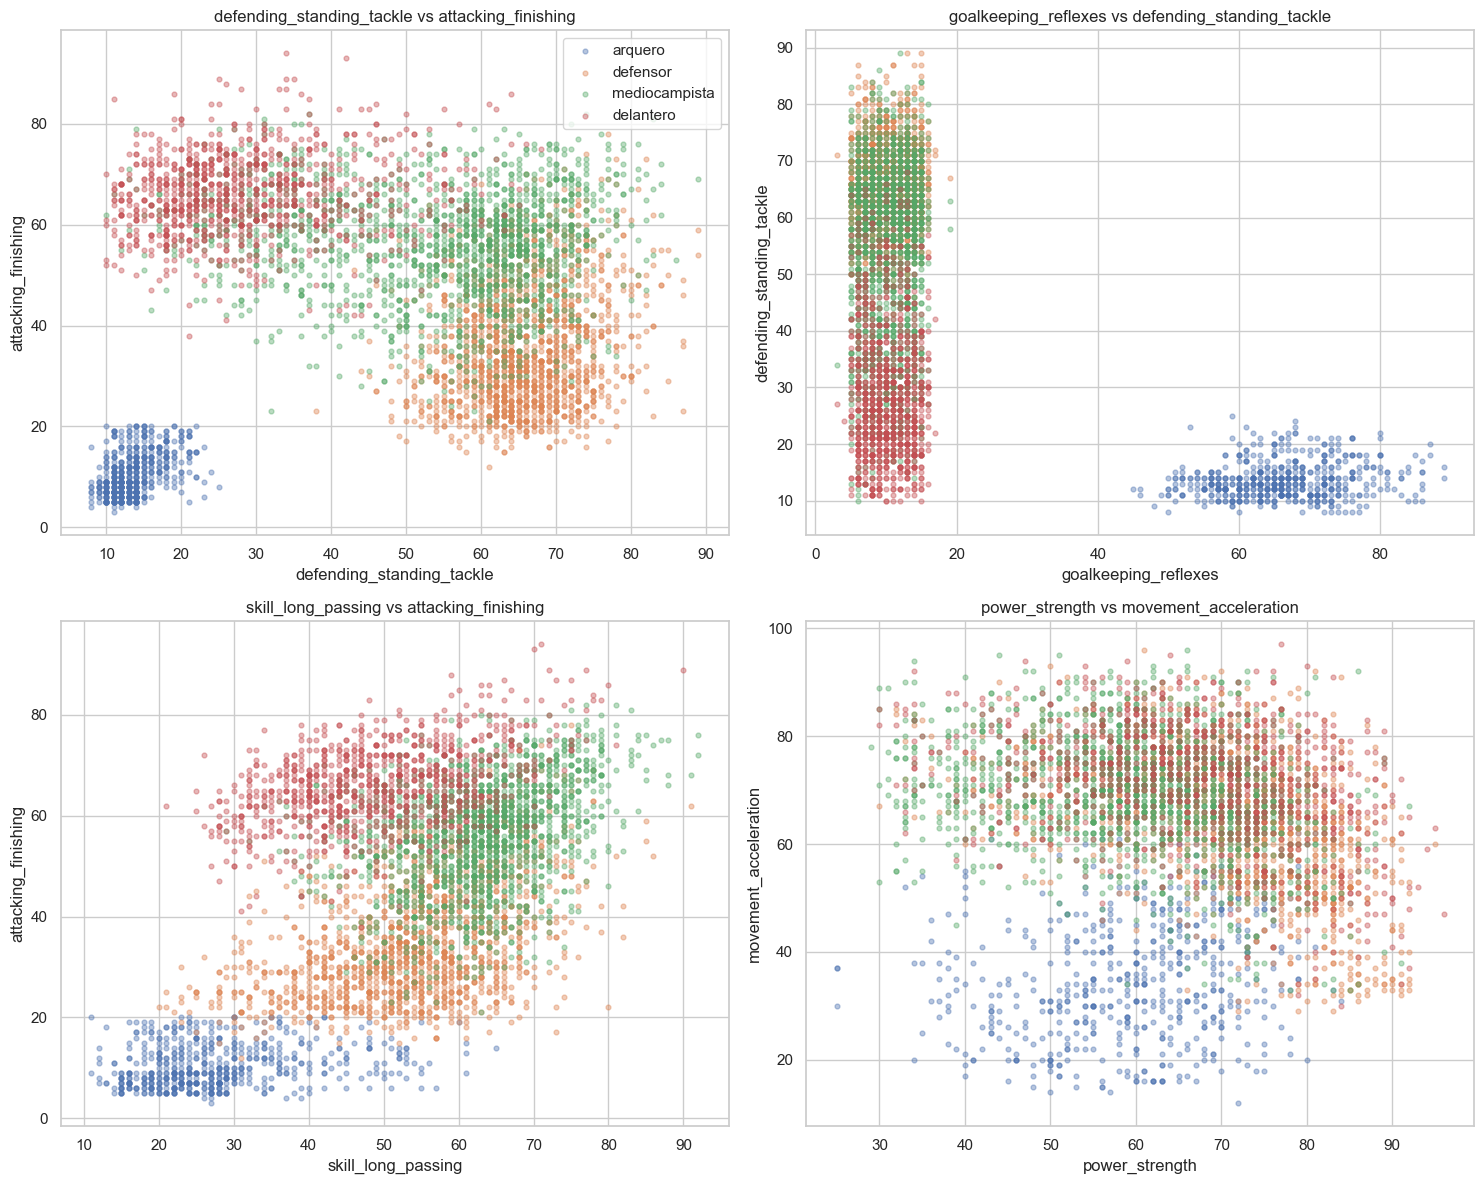

In [45]:
# muestra para que no explote con 180k puntos
muestra = male_players_limpio.sample(5000, random_state=42)
orden = ["arquero", "defensor", "mediocampista", "delantero"]

# pares elegidos para mostrar distintos ejes de separación
pares = [
    ("defending_standing_tackle", "attacking_finishing"),   # eje defensa vs ataque (el clásico)
    ("goalkeeping_reflexes", "defending_standing_tackle"),   # aísla arqueros
    ("skill_long_passing", "attacking_finishing"),           # creación vs definición
    ("power_strength", "movement_acceleration"),             # físico vs velocidad
]

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
for ax, (x, y) in zip(axes.flat, pares):
    for rol in orden:
        sub = muestra[muestra["rol"] == rol]
        ax.scatter(sub[x], sub[y], s=12, alpha=0.4, label=rol)
    ax.set_xlabel(x); ax.set_ylabel(y)
    ax.set_title(f"{x} vs {y}")
axes.flat[0].legend()
plt.tight_layout()
plt.show()

#### Variables categoricas

In [29]:
categoricas = male_players_limpio.select_dtypes(include=["object", "category"])
print(f"{categoricas.shape[1]} columnas categóricas:")
categoricas_list = categoricas.columns.tolist()
print(categoricas_list)

2 columnas categóricas:
['long_name', 'rol']


In [30]:
male_players_limpio[categoricas_list].describe()

,long_name,rol
count,18350,18350
unique,18329,4
top,Tyler Roberts,mediocampista
freq,2,6673


In [31]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. Subconjunto de campo (sin arqueros)
campo = male_players_limpio[male_players_limpio["rol"] != "arquero"].copy()
print(f"Jugadores de campo: {len(campo):,}")

# 2. Las granulares presentes
gran = [c for c in grupos_dominio["granulares"] if c in campo.columns]
print(f"Granulares: {len(gran)} variables")

# 3. CHEQUEO CLAVE: ¿quedan nulos en las granulares tras sacar arqueros?
nulos_gran = campo[gran].isna().sum()
print("\nGranulares con nulos (deberían ser 0 o muy pocos):")
print(nulos_gran[nulos_gran > 0] if nulos_gran.sum() > 0 else "Ninguna, limpio ✓")

Jugadores de campo: 16,305
Granulares: 29 variables

Granulares con nulos (deberían ser 0 o muy pocos):
Ninguna, limpio ✓


In [32]:
# 4. Escalar (imprescindible) y hacer PCA
X_gran = campo[gran]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_gran)

# n_components=0.90 → PCA elige cuántas comp. hacen falta para el 90% de varianza
pca = PCA(n_components=0.90)
X_pca = pca.fit_transform(X_scaled)

print(f"{len(gran)} granulares → {pca.n_components_} componentes (90% varianza)")
print(f"\nVarianza por componente:")
for i, v in enumerate(pca.explained_variance_ratio_):
    print(f"  PC{i+1}: {v*100:5.1f}%")

29 granulares → 10 componentes (90% varianza)

Varianza por componente:
  PC1:  40.0%
  PC2:  22.8%
  PC3:  10.9%
  PC4:   6.4%
  PC5:   2.5%
  PC6:   2.0%
  PC7:   1.8%
  PC8:   1.4%
  PC9:   1.3%
  PC10:   1.2%


In [33]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# X_pca son las 10 componentes que ya calculaste (90% varianza, sobre datos ya deduplicados)
# Usamos sample_size para que el cálculo de silhouette sea rápido incluso si el dataset crece
sils_km = {}
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_pca)
    sil = silhouette_score(X_pca, labels, sample_size=5000, random_state=42)
    sils_km[k] = sil
    print(f"k={k}: silueta = {sil:.3f} | inercia = {km.inertia_:,.0f} | tamaños = {np.bincount(labels)}")

k=2: silueta = 0.249 | inercia = 302,890 | tamaños = [6755 9550]
k=3: silueta = 0.241 | inercia = 242,228 | tamaños = [4940 6041 5324]
k=4: silueta = 0.208 | inercia = 213,885 | tamaños = [3397 4875 4376 3657]
k=5: silueta = 0.207 | inercia = 192,913 | tamaños = [3190 4380 3220 3063 2452]
k=6: silueta = 0.203 | inercia = 178,076 | tamaños = [2634 2414 2487 2709 1921 4140]
k=7: silueta = 0.193 | inercia = 164,916 | tamaños = [2195 2182 3798 2501 1720 2185 1724]
k=8: silueta = 0.186 | inercia = 155,517 | tamaños = [1987 1898 3366 2054 1657 1613 1808 1922]


El silhouette es más alto en `k=2` (0.250) y `k=3` (0.243), pero esos valores son demasiado gruesos para el objetivo del práctico: con solo 2-3 clusters no se puede distinguir bien roles como para pensar reemplazos concretos dentro de un plantel. A partir de `k=4` el silhouette baja y se estabiliza en el rango 0.18-0.21 antes de seguir cayendo. **Elegimos `k=5`** como compromiso entre cohesión estadística razonable e interpretabilidad futbolística (ver el análisis cualitativo más abajo).

### Segunda técnica: clustering jerárquico aglomerativo (Ward)

Para cumplir con la consigna de comparar al menos dos técnicas, probamos también aglomerativo con linkage Ward (mismo criterio de minimizar varianza intra-cluster que optimiza K-Means, para que la comparación sea justa) sobre el mismo `X_pca`.

In [34]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score

sils_ac = {}
for k in range(2, 9):
    ac = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = ac.fit_predict(X_pca)
    sil = silhouette_score(X_pca, labels, sample_size=5000, random_state=42)
    sils_ac[k] = sil
    print(f"k={k}: silueta = {sil:.3f} | tamaños = {np.bincount(labels)}")

comparacion = pd.DataFrame({'KMeans': sils_km, 'Agglomerative (Ward)': sils_ac}).round(4)
comparacion.index.name = 'k'
comparacion

k=2: silueta = 0.222 | tamaños = [10132  6173]
k=3: silueta = 0.209 | tamaños = [6173 5767 4365]
k=4: silueta = 0.159 | tamaños = [5767 3441 4365 2732]
k=5: silueta = 0.140 | tamaños = [4365 3441 2299 2732 3468]
k=6: silueta = 0.139 | tamaños = [3441 2143 2299 2732 3468 2222]
k=7: silueta = 0.136 | tamaños = [2299 2143 1779 2732 3468 2222 1662]
k=8: silueta = 0.137 | tamaños = [2143 2732 1779 1447 3468 2222 1662  852]


,KMeans,Agglomerative (Ward)
k,,
2,0.2490,0.2221
3,0.2415,0.2088
4,0.2081,0.1591
5,0.2073,0.1400
6,0.2030,0.1387
7,0.1931,0.1360
8,0.1859,0.1374


**Elegimos K-Means con `k=5`** como resultado principal: para todo `k` evaluado, K-Means tiene mayor silhouette que Agglomerative (Ward), es decir, produce clusters más compactos y mejor separados en este espacio de 10 componentes principales. Calculamos también el **Adjusted Rand Index** entre ambos métodos con `k=5` para ver qué tan de acuerdo están.

In [35]:
km_final = KMeans(n_clusters=5, random_state=42, n_init=10).fit(X_pca)
campo['cluster'] = km_final.labels_

ac_final_labels = AgglomerativeClustering(n_clusters=5, linkage='ward').fit_predict(X_pca)
ari = adjusted_rand_score(km_final.labels_, ac_final_labels)
print(f'Adjusted Rand Index (KMeans vs. Agglomerative, k=5): {ari:.3f}')
print(f'Silhouette final (KMeans, k=5): {sils_km[5]:.4f}')

print('\nTamaño de cada cluster:')
print(campo['cluster'].value_counts().sort_index())

Adjusted Rand Index (KMeans vs. Agglomerative, k=5): 0.380
Silhouette final (KMeans, k=5): 0.2073

Tamaño de cada cluster:
cluster
0    3190
1    4380
2    3220
3    3063
4    2452
Name: count, dtype: int64


## Análisis cualitativo de los clusters

Cruzamos los clusters contra el `rol` macro (arquero/defensor/mediocampista/delantero, ya excluimos arqueros de este clustering) y contra algunos atributos granulares clave para entender qué representa cada grupo.

In [36]:
print('Composición de rol por cluster:')
print(pd.crosstab(campo['cluster'], campo['rol']))

key_attrs = ['attacking_finishing', 'skill_dribbling', 'skill_long_passing', 'movement_sprint_speed',
             'defending_marking_awareness', 'defending_standing_tackle', 'power_strength',
             'mentality_interceptions']

perfil = campo.groupby('cluster')[key_attrs + ['overall']].mean().round(1)
perfil['size'] = campo['cluster'].value_counts().sort_index()
perfil

Composición de rol por cluster:
rol      defensor  delantero  mediocampista
cluster                                    
0            2935          9            246
1            2444         36           1900
2             495        534           2191
3             300        836           1927
4               0       2043            409


,attacking_finishing,skill_dribbling,skill_long_passing,movement_sprint_speed,defending_marking_awareness,defending_standing_tackle,power_strength,mentality_interceptions,overall,size
cluster,,,,,,,,,,
0,28.8,45.0,49.1,60.3,61.0,63.5,71.9,60.6,62.6,3190
1,45.6,62.0,61.7,68.1,63.1,65.5,68.6,63.8,67.2,4380
2,64.9,73.2,69.0,71.4,56.5,58.8,65.0,57.9,73.0,3220
3,53.1,61.7,51.8,71.2,35.9,38.5,50.9,35.1,59.8,3063
4,67.3,65.6,49.2,72.1,27.7,26.8,71.3,25.9,66.8,2452


In [37]:
print('Jugadores de mayor overall por cluster (para reconocer nombres reales):')
print('(usamos long_name y rol; short_name, player_positions y club_position fueron descartadas en la selección de variables)')
for c in sorted(campo['cluster'].unique()):
    top = campo[campo['cluster'] == c].sort_values('overall', ascending=False).head(4)
    print(f'\nCluster {c}:')
    print(top[['long_name', 'rol', 'overall']].to_string(index=False))

Jugadores de mayor overall por cluster (para reconocer nombres reales):
(usamos long_name y rol; short_name, player_positions y club_position fueron descartadas en la selección de variables)

Cluster 0:
         long_name      rol  overall
Vilmos Tamás Orban defensor       83
  Robin Le Normand defensor       82
      Joseph Aidoo defensor       79
Axel Arthur Disasi defensor       79

Cluster 1:
                       long_name      rol  overall
Rúben dos Santos Gato Alves Dias defensor       89
 Ronald Federico Araújo da Silva defensor       86
            Éder Gabriel Militão defensor       86
                Matthijs de Ligt defensor       86

Cluster 2:
                     long_name           rol  overall
          Kylian Mbappé Lottin     delantero       91
          Erling Braut Haaland     delantero       91
               Kevin De Bruyne mediocampista       91
Lionel Andrés Messi Cuccittini     delantero       90

Cluster 3:
                        long_name           rol  ov

### Interpretación de cada cluster

- **Cluster 0 — Centrales de rotación/menor jerarquía** (n=3.190; overall 62.6, el más bajo entre los perfiles defensivos; casi puro `defensor`, con Orban, Le Normand, Disasi, Aidoo). `defending_marking_awareness` 61.0 y `standing_tackle` 63.5 decentes, pero `finishing` el más bajo de todos (28.8), poco móviles (`sprint_speed` 60.3) y físicamente duros (`power_strength` 71.9). Representa al central de nivel medio, sólido pero sin mucha proyección ofensiva — equivalentes entre sí como reemplazos directos de un CB de rotación.
- **Cluster 1 — Centrales/mediocampistas defensivos de élite** (n=4.380, el **cluster más grande**; overall 67.2; mezcla de `defensor` y `mediocampista`, con Rúben Dias, Araujo, De Ligt, Militão). Tiene el `standing_tackle` (65.5) y `mentality_interceptions` (63.8) más altos de todos los clusters, además de buen `dribbling` (62.0) y `long_passing` (61.7) para un perfil defensivo. Representa al defensor/mediocampista de contención de primer nivel: fuerte, disciplinado y con participación real en la salida de juego. Son razonablemente equivalentes entre sí como candidatos a reemplazo directo de un titular defensivo de alta gama.
- **Cluster 2 — Jugadores de élite, todas las posiciones** (n=3.220; el de **mayor overall promedio, 73.0**, por lejos el más alto de los 5). Mezcla explícita de roles: 495 `defensor`, 534 `delantero`, 2.191 `mediocampista`, con Mbappé, Haaland, De Bruyne y Messi juntos. Tiene los valores más altos en `dribbling` (73.2) y `skill_long_passing` (69.0), y buen `finishing` (64.9) simultáneamente — una combinación que normalmente no convive en un solo rol. **Es el caso de heterogeneidad más interesante**: agrupa a los jugadores de clase mundial de cualquier posición, porque en el espacio de atributos reducido por PCA, ser excelente en general pesa más en la distancia que jugar en una posición específica. Para el objetivo concreto del práctico (sustituir a un jugador lesionado) este cluster **no es directamente utilizable tal cual** — haría falta cruzarlo con `rol` como filtro adicional antes de proponer un reemplazo.
- **Cluster 3 — Jóvenes/reservas de banda y ataque, nivel modesto** (n=3.063; overall 59.8, el **más bajo del grupo**; mezcla `mediocampista`/`delantero` con algo de `defensor`, con Conceição, Jeffinho, Dimeira, Ezzalzouli). `sprint_speed` alto (71.2) pero `defending` muy bajo (35.9/38.5) y `power_strength` bajo (50.9). Representa jugadores de banda todavía en desarrollo, de clubes chicos o filiales, sin un rol totalmente definido.
- **Cluster 4 — Delanteros finalizadores puros** (n=2.452; casi exclusivamente `delantero` (2.043 de 2.452), con Vlahović, Boulaye Dia, En-Nesyri e Iago Aspas). `attacking_finishing` el más alto de todos (67.3), buen `dribbling` (65.6) y velocidad (72.1), pero `defending` el más bajo de cualquier cluster (27.7/26.8/25.9) y `long_passing` bajo (49.2). El arquetipo del "9" rematador — un cluster bien definido y coherente.

### ¿Qué explica las diferencias de tamaño?

El cluster más grande (1, defensivo de élite) y el más chico (4, finalizadores puros) reflejan la misma lógica de pirámide competitiva: cualquier plantel necesita más defensores/contenedores sólidos que delanteros especializados de área. El cluster 2 (élite transversal) es intermedio en tamaño porque agrupa a los mejores jugadores de **todas** las posiciones de campo a la vez, no a un rol específico — es "chico" relativo al total de jugadores de campo, pero grande en relación a cuántos jugadores de nivel mundial existen en total. El cluster 3 (jóvenes de banda, nivel modesto) es grande porque incluye a todos los jugadores todavía sin rol definido de equipos chicos o filiales, que son mayoría en las ligas menores del dataset.

## ¿Se normalizó/escaló la base? ¿Por qué?

**Sí.** Antes de aplicar PCA y clustering, escalamos las 28 variables granulares con `StandardScaler` (media 0, desvío 1). Es necesario porque, aunque todas están en la escala nominal 0-99 de EA, tienen dispersiones distintas entre sí (por ejemplo `defending_marking_awareness` tiene mucha más varianza que `movement_reactions`, ver la tabla de estadística descriptiva más arriba). Sin escalar, PCA — que busca las direcciones de mayor varianza — quedaría dominado por las variables de mayor dispersión aunque no sean más relevantes desde el punto de vista futbolístico, y lo mismo pasaría después con las distancias euclídeas que usan K-Means y el clustering jerárquico. Escalar pone a las 28 dimensiones en pie de igualdad antes de reducir dimensionalidad y clusterizar.

No incluimos `value_eur`, `wage_eur` ni variables físicas (`height_cm`, `weight_kg`) en este escalado porque ya las habíamos descartado del conjunto de clustering en la selección de variables (reflejan mercado/físico, no habilidad pura).

## Proyección/Embedding: PCA como preprocesado y para visualizar

Ya usamos PCA como **preprocesado** para clusterizar (redujimos 28 atributos granulares a 10 componentes que explican el 90% de la varianza, y clusterizamos sobre esas 10 componentes). Ahora usamos las dos primeras componentes para **visualizar** el resultado en 2D.

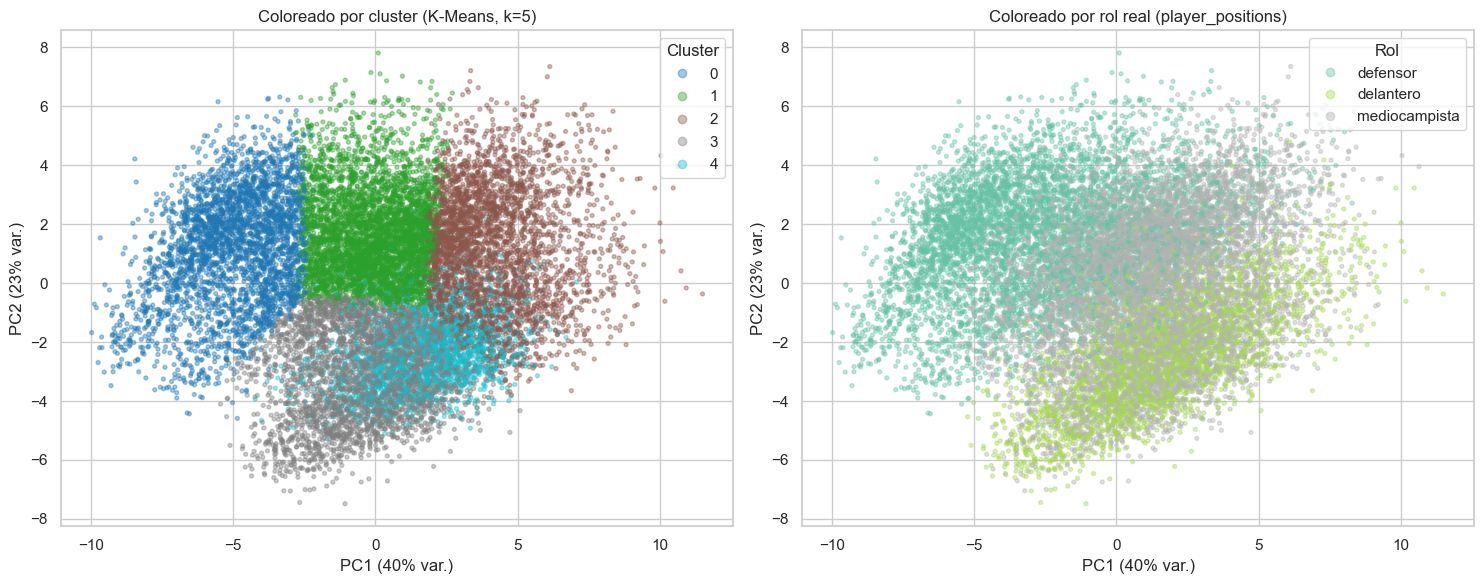

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sc1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=campo['cluster'], cmap='tab10', alpha=0.4, s=8)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.0f}% var.)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.0f}% var.)')
axes[0].set_title('Coloreado por cluster (K-Means, k=5)')
axes[0].legend(*sc1.legend_elements(), title='Cluster', loc='upper right')

rol_codes = campo['rol'].astype('category').cat.codes
sc2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=rol_codes, cmap='Set2', alpha=0.4, s=8)
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.0f}% var.)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.0f}% var.)')
axes[1].set_title('Coloreado por rol real (player_positions)')
handles, _ = sc2.legend_elements()
axes[1].legend(handles, campo['rol'].astype('category').cat.categories, title='Rol', loc='upper right')

plt.tight_layout()
plt.show()

Al comparar ambos paneles se entiende mejor por qué el cluster 2 (élite transversal) es heterogéneo en posición: sus puntos caen en el extremo derecho de `PC1`, una zona que solo alcanzan los jugadores más sobresalientes de **cada** rol (defensores, mediocampistas y delanteros por igual), no una zona reservada a un rol en particular. Es decir, `PC1` no separa puramente por posición sino que también captura buena parte del nivel general del jugador — coherente con que el cluster 2 tenga, por lejos, el mayor `overall` promedio (73.0 vs. 59.8-67.2 en el resto).

## Clustering de arqueros (población separada)

En todo el análisis anterior excluimos a los arqueros porque no tienen los 28 atributos granulares de campo (son estructuralmente nulos para ellos, ver el chequeo de missing values). Pero un arquero nunca sería reemplazado por un jugador de campo ante una lesión, así que conviene igual encontrarles sus propios grupos de equivalencia, usando sus 5 atributos específicos.

In [39]:
gk_cols = ['goalkeeping_diving', 'goalkeeping_handling', 'goalkeeping_kicking',
           'goalkeeping_positioning', 'goalkeeping_reflexes']

arqueros = male_players_limpio[male_players_limpio['rol'] == 'arquero'].copy()
print('Arqueros:', arqueros.shape[0])
print('Nulos en atributos de arquero:', arqueros[gk_cols].isna().sum().sum())

X_gk = arqueros[gk_cols]
Xs_gk = StandardScaler().fit_transform(X_gk)

for k in [2, 3, 4, 5]:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(Xs_gk)
    sil = silhouette_score(Xs_gk, km.labels_)
    print(f'k={k}: silueta={sil:.4f} tamaños={np.bincount(km.labels_)}')

Arqueros: 2045
Nulos en atributos de arquero: 0
k=2: silueta=0.4568 tamaños=[ 913 1132]
k=3: silueta=0.4018 tamaños=[905 662 478]
k=4: silueta=0.3454 tamaños=[481 585 751 228]
k=5: silueta=0.3172 tamaños=[635 150 340 413 507]


In [40]:
km_gk = KMeans(n_clusters=3, random_state=42, n_init=10).fit(Xs_gk)
arqueros['cluster'] = km_gk.labels_

perfil_gk = arqueros.groupby('cluster')[gk_cols + ['overall']].mean().round(1)
perfil_gk['size'] = arqueros['cluster'].value_counts().sort_index()
print(perfil_gk)

for c in sorted(arqueros['cluster'].unique()):
    top = arqueros[arqueros['cluster'] == c].sort_values('overall', ascending=False).head(4)
    print(f'\nCluster {c}:')
    print(top[['long_name', 'overall']].to_string(index=False))

         goalkeeping_diving  goalkeeping_handling  goalkeeping_kicking  \
cluster                                                                  
0                      65.5                  63.2                 62.3   
1                      57.0                  55.5                 54.9   
2                      74.4                  72.2                 71.2   

         goalkeeping_positioning  goalkeeping_reflexes  overall  size  
cluster                                                                
0                           64.0                  66.4     65.0   905  
1                           54.4                  57.4     56.1   662  
2                           73.6                  75.9     74.4   478  

Cluster 0:
                 long_name  overall
   Ralf Sebastian Fährmann       72
           Marius Gersbeck       72
        Christian Mathenia       72
Horaţiu Alexandru Moldovan       71

Cluster 1:
                 long_name  overall
Sander Luan Asevedo Cirino   

A diferencia de los jugadores de campo, los 5 atributos de arquero están muy correlacionados entre sí (un arquero bueno en una faceta suele serlo en varias), así que los 3 clusters no separan "estilos" de arquero sino directamente **niveles de calidad general**: un cluster de arqueros jóvenes/en desarrollo con overall bajo, uno intermedio, y un cluster de élite (Courtois, Alisson, Ter Stegen, Ederson tipo de perfil) con todos los atributos claramente por encima del resto. Tiene sentido: el arquero moderno de élite necesita ser bueno en todas las facetas (atajar, salir, jugar con los pies) a la vez, a diferencia del campo donde sí hay especialización de rol clara.

## Comparación de interpretaciones: humano vs. LLMs

### Paquete de datos a presentar a los modelos

Le damos a Claude, ChatGPT y Gemini **exactamente la misma información numérica** sobre el clustering principal (K-Means, k=5, jugadores de campo): la tabla de centroides (medias por cluster, sin escalar, en las variables granulares originales), el tamaño de cada cluster, y la lista de variables usadas — **sin nuestra interpretación**, para no sesgarlos.

In [41]:
llm_table = campo.groupby('cluster')[key_attrs + ['overall']].mean().round(1)
llm_table['size'] = campo['cluster'].value_counts().sort_index()
llm_table['size_pct'] = (llm_table['size'] / len(campo) * 100).round(1)
print(llm_table.to_markdown())

|   cluster |   attacking_finishing |   skill_dribbling |   skill_long_passing |   movement_sprint_speed |   defending_marking_awareness |   defending_standing_tackle |   power_strength |   mentality_interceptions |   overall |   size |   size_pct |
|----------:|----------------------:|------------------:|---------------------:|------------------------:|------------------------------:|----------------------------:|-----------------:|--------------------------:|----------:|-------:|-----------:|
|         0 |                  28.8 |              45   |                 49.1 |                    60.3 |                          61   |                        63.5 |             71.9 |                      60.6 |      62.6 |   3190 |       19.6 |
|         1 |                  45.6 |              62   |                 61.7 |                    68.1 |                          63.1 |                        65.5 |             68.6 |                      63.8 |      67.2 |   4380 |       26.9 |


### Prompt (idéntico para los tres modelos)

> Tengo un clustering K-Means (k=5) hecho sobre jugadores de fútbol profesional de campo (EA Sports FC 24, arqueros excluidos). Usé 28 atributos granulares de habilidad (escala 0-99, estandarizados con `StandardScaler`), reducidos con PCA a 10 componentes (90% de varianza) antes de clusterizar. La tabla de abajo no muestra las 28 variables completas, sino los centroides (medias sin escalar) en 8 de esos atributos elegidos por representatividad (`attacking_finishing`, `skill_dribbling`, `skill_long_passing`, `movement_sprint_speed`, `defending_marking_awareness`, `defending_standing_tackle`, `power_strength`, `mentality_interceptions`), junto con `overall` promedio y el tamaño de cada uno:
>
> [pegar aquí la tabla markdown generada arriba]
>
> Interpretá los 5 clusters: ¿qué representa cada uno? ¿Los jugadores dentro de un mismo cluster son "equivalentes" entre sí (es decir, podrían ocupar el mismo rol/posición en un equipo)? ¿Qué podría explicar la heterogeneidad interna o las diferencias de tamaño entre los grupos?

### Respuestas de los tres modelos

**Interpretación de Claude** (generada solo a partir de la tabla de centroides, sin la interpretación de dominio de la sección anterior):

> Los 5 clusters parecen dividirse principalmente entre perfiles defensivos y ofensivos, con una dimensión adicional de nivel general. Dos clusters muestran `defending_marking_awareness` y `defending_standing_tackle` altos con `attacking_finishing` bajo — probablemente defensores centrales — pero uno de ellos tiene `overall` notablemente más alto que el otro, lo que sugiere que en realidad hay dos niveles de calidad dentro del mismo rol defensivo (un grupo de defensores de élite y otro de nivel más estándar), no dos estilos distintos. Un cluster tiene `attacking_finishing` y `skill_dribbling` altos con `defending` muy bajo: probablemente delanteros rematadores. Otro cluster tiene todos los valores relativamente bajos, con `overall` el más bajo del grupo — posiblemente jugadores jóvenes o de menor nivel, todavía sin definir un rol claro. El quinto cluster combina valores altos en variables típicamente opuestas (buen `defending_marking_awareness` junto con buen `attacking_finishing`, algo inusual) y tiene el `overall` más alto de todos — esto sugiere que agrupa a los jugadores de mayor nivel general sin importar su posición específica, ya que un jugador excelente suele tener puntajes altos en casi todas las dimensiones evaluadas.
>
> En cuanto a la equivalencia: es razonable asumir que los clusters con perfiles claramente unidireccionales (muy defensivo o muy ofensivo) agrupan jugadores intercambiables en un mismo rol. El cluster de mayor nivel general, sin embargo, probablemente no es homogéneo en términos de posición — mezclar defensivo y ofensivo alto simultáneamente no es un patrón típico de un solo rol, sino más bien indicio de que agrupa a los "mejores jugadores" de varias posiciones distintas. Las diferencias de tamaño probablemente reflejan que en cualquier plantel de fútbol profesional hay más jugadores de nivel medio-bajo que de élite, y que ciertos roles (como el defensivo) requieren más dotación de plantel que otros.

**Respuesta de Gemini:**

> Este análisis muestra cómo K-Means organizó a los futbolistas de EA FC 24 basándose en sus perfiles técnicos, físicos y tácticos.
>
> **1. Interpretación de los Clusters (Perfiles y Archetypes)**
>
> Analizando los valores promedio en la escala 0–99 de cada variable, podemos asignar un "perfil de rol" a cada grupo:
>
> - **Cluster 0 (19.6%) — Defensivos Puros (Defensa Central / Pivote).** Def: ~62 | Ataque: 28.8 | Overall: 62.6. Atributos clave: alta conciencia defensiva (61.0), entrada de pie (63.5) e intercepciones (60.6) con gran fuerza (71.9), pero un ataque nulo (finishing 28.8). Representa: defensas centrales (CB) de perfil clásico y pivotes puramente defensivos (MCD). Son jugadores físicos y destructivos pero limitados con la pelota.
> - **Cluster 1 (26.9%) — Todoterrenos / Mediocampistas Completos.** Def: ~64 | Pase: 61.7 | Overall: 67.2. El grupo más equilibrado: buena defensa, buen pase, buen regate (62.0) y fuerza sólida (68.6). Representa: mediocampistas centrales (MC), carrileros completos, laterales con ida y vuelta, o centrales modernos con aceptable salida de balón.
> - **Cluster 2 (19.7%) — Élite / Jugadores Creativos Completos.** Regate: 73.2 | Pase: 69.0 | Overall: 73.0. Es el grupo con mayor overall promedio. Dominan el regate, el pase largo y el remate (64.9), manteniendo un nivel aceptable de velocidad y fuerza. Representa: mediapuntas (MCO), extremos de alto nivel y mediocampistas organizadores top — aquí se agrupan los futbolistas con mayor calidad técnica global.
> - **Cluster 3 (18.8%) — Atacantes/Volantes Periféricos (Perfil Bajo/Nivel Desarrollo).** Vel: 71.2 | Def: ~36 | Overall: 59.8. Veloces y aceptables en regate, pero muy débiles en defensa y con fuerza reducida (50.9); tienen el overall más bajo. Representa: extremos o volantes jóvenes/en desarrollo, jugadores de ligas menores o revulsivos que destacan por velocidad pero aún carecen de físico y gol.
> - **Cluster 4 (15.0%) — Delanteros Físicos y Rematadores (Nueve / Área).** Remate: 67.3 | Fuerza: 71.3 | Def: ~26 | Overall: 66.8. El mayor valor de remate, alta velocidad (72.1) y mucha fuerza, con métricas defensivas casi nulas. Representa: delanteros centro (DC) de área, arietes físicos y extremos orientados al gol.
>
> **2. ¿Son "equivalentes" los jugadores dentro de un mismo cluster?**
>
> Respuesta corta: no necesariamente. Comparten un "perfil de habilidades", pero no siempre pueden intercambiarse o jugar en la misma posición. Un algoritmo de clustering agrupa por similitud multidimensional de atributos, no por posición táctica. Esto genera dos efectos clave:
>
> - *Diferentes posiciones, mismo cluster*: en el Cluster 0 conviven un defensa central duro de 1.93 m y un pivote defensivo de 1.75 m — mismas habilidades técnicas (saben defender y no saben definir), pero estatura/peso y rol táctico difieren. En el Cluster 2 puedes encontrar tanto a un extremo de clase mundial como a un mediapunta o a un carrilero ofensivo de gran nivel.
> - *Efecto "Nivel de Calidad" vs. "Posición"*: el algoritmo separó a los jugadores ofensivos en dos clusters principales no por dónde juegan, sino por qué tan buenos son — el Cluster 2 agrupa a la élite ofensiva/creativa (overall 73.0), mientras que el Cluster 3 agrupa a atacantes de menor calidad/desarrollo (overall 59.8). Por ende, un jugador del Cluster 3 no puede reemplazar a uno del Cluster 2 en la alineación titular sin causar un salto drástico en el rendimiento.
>
> **3. Factores que explican la heterogeneidad interna y los tamaños**
>
> - *Distribución de los datos*: el gran tamaño del Cluster 1 (26.9%, 4.380 jugadores) refleja que la mayoría de los futbolistas de nivel medio en ligas secundarias o posiciones de mediocampo/lateral tienden a ser "promedio" en múltiples áreas sin hiper-especializarse; la densidad poblacional cerca de la media global atrae a la mayor cantidad de observaciones. El menor tamaño del Cluster 4 (15.0%, 2.452 jugadores) se debe a que los atacantes puros con alto remate y mucha fuerza son un perfil más específico dentro del universo total de jugadores de campo.
> - *"Efecto mediana" y calidad global (overall)*: los 8 atributos seleccionados capturan la calidad técnica general, por lo que el Cluster 2 actúa como un embudo de jugadores con alto rating general; la varianza dentro de ese cluster se debe a que mezcla organizadores (alto pase, bajo remate) con delanteros estelares (alto remate, pase moderado) que comparten una base de habilidad alta.
> - *Ausencia de variables físico-espaciales*: el clustering no incluyó atributos antropométricos (estatura, peso, pie preferido) ni posiciones predeterminadas. Si se incluyera la estatura, el Cluster 0 se dividiría claramente entre centrales (altos) y mediocampistas defensivos/laterales (más bajos).
>
> **Conclusión**: el modelo logró una excelente segmentación funcional (Cluster 0: especialistas defensivos/físicos; Cluster 1: el "motor" de nivel medio/mixto; Cluster 2: la élite técnica y creadora; Cluster 3: jugadores de banda/desarrollo de baja media; Cluster 4: rematadores y atacantes de área), pero para determinar equivalencia directa de reemplazo (sustituibilidad táctica) convendría filtrar adicionalmente por posición preferida, estatura y pie dominante.

**Respuesta de ChatGPT:**

> Sí. La lectura más interesante es que los clusters no parecen representar simplemente "posiciones", sino perfiles de habilidad/estilo de jugador. Esto es importante porque las 8 variables mezclan dimensiones ofensivas, defensivas, físicas y de movilidad.
>
> **1. Cluster 0 — Defensivo/físico, limitado técnicamente** (3.190 jugadores, 19.6%). Finishing 28.8 (muy bajo), dribbling 45.0, long passing 49.1, sprint 60.3, marking 61.0, standing tackle 63.5, strength 71.9, interceptions 60.6, overall 62.6. Perfil defensivo y físico con poca capacidad ofensiva — probablemente centrales, mediocampistas defensivos, algunos laterales defensivos y jugadores físicos de bajo nivel técnico. La combinación strength+tackling+marking+interceptions, muy superior a finishing/dribbling, sugiere jugadores cuya contribución principal es recuperar y disputar la pelota, más que crear o finalizar.
>
> **2. Cluster 1 — Perfil equilibrado/intermedio** (4.380 jugadores, 26.9%, el más grande). Valores bastante parejos: finishing 45.6, dribbling 62.0, passing 61.7, sprint 68.1, marking 63.1, tackling 65.5, strength 68.6, interceptions 63.8, overall 67.2. No hay una dimensión extremadamente dominante — un perfil generalista, capaz de desempeñarse razonablemente bien en varias fases del juego (mediocampistas centrales, defensivos, laterales, centrales con buen manejo de pelota). Es lógico que sea el cluster más grande: agrupa jugadores de muchas posiciones usando solo 8 atributos, funcionando como una especie de "centro" del espacio de jugadores de campo.
>
> **3. Cluster 2 — Ofensivo/técnico** (3.220 jugadores, 19.7%, mayor overall promedio: 73.0). Finishing 64.9, dribbling 73.2, long passing 69.0, sprint 71.4, marking 56.5, tackling 58.8, strength 65.0, interceptions 57.9. Patrón claro de técnica + capacidad ofensiva + movilidad, con menor énfasis defensivo — probablemente extremos, mediapuntas, delanteros, interiores ofensivos y algunos mediocampistas creativos. No necesariamente todos "atacantes puros": un mediocampista ofensivo puede tener un perfil muy parecido a un extremo según estos 8 atributos.
>
> **4. Cluster 3 — Rápido/ofensivo pero defensivamente débil** (3.063 jugadores, 18.8%). Finishing 53.1, dribbling 61.7, passing 51.8, sprint 71.2, marking 35.9, tackling 38.5, strength 50.9, interceptions 35.1, overall 59.8 (el más bajo). La característica dominante es velocidad + cierta capacidad ofensiva + muy poca capacidad defensiva/física — probablemente extremos rápidos, delanteros secundarios, atacantes jóvenes/de menor overall, laterales muy ofensivos y jugadores de banda con poca capacidad defensiva.
>
> **5. Cluster 4 — Atacante potente/finalizador** (2.452 jugadores, 15.0%, el más pequeño). Finishing 67.3, dribbling 65.6, passing 49.2, sprint 72.1, marking 27.7, tackling 26.8, strength 71.3, interceptions 25.9, overall 66.8. Jugador ofensivo, rápido y fuerte, con poca participación defensiva — delanteros, delanteros centro, extremos físicos, atacantes cerca del área. El long passing relativamente bajo diferencia este grupo del Cluster 2.
>
> Hay una separación interesante entre Cluster 2 (atacante técnico/creativo) y Cluster 4 (atacante físico/finalizador), y entre Cluster 3 (rápido pero relativamente débil y poco efectivo) y Cluster 4 (rápido y fuerte, con mucha mayor capacidad de definición).
>
> **¿Son "equivalentes" los jugadores dentro de un cluster? No.** Estar en el mismo cluster no significa que dos jugadores sean intercambiables ni que puedan ocupar la misma posición. K-Means solo dice que esos jugadores están relativamente cerca entre sí según las variables utilizadas para construir el espacio. Por ejemplo, en el Cluster 2 un extremo con mucho dribbling/velocidad/finishing y un mediapunta con buen passing/dribbling/finishing pueden compartir cluster porque sus atributos están cerca del centroide, pero tácticamente no son equivalentes. Esto ocurre porque el clustering se hizo sobre solo 8 atributos, que no contienen información explícita sobre posición, altura, pie preferido, work rates, visión, crossing, ball control, heading, jumping, stamina, composure, positioning, etc.
>
> **Sobre la heterogeneidad dentro de cada cluster:** es completamente esperable. K-Means minimiza la distancia de los jugadores respecto del centroide, pero no busca que todos los jugadores tengan exactamente las mismas características — el centroide es solo el promedio. Por ejemplo, `finishing = 64.9` en el Cluster 2 no significa que todos tengan finishing ≈ 65; puede haber jugadores con 55, 60, 70 u 80 si la combinación del resto de sus variables los acerca igual al centroide. No conviene interpretar el centroide como un jugador real.
>
> **Sobre los tamaños de los clusters:** son razonables (ninguno absurdamente chico o dominante). Se explican por (1) la distribución real de jugadores en el espacio de habilidades — hay muchos más jugadores "intermedios" que perfiles extremos, lo que explica que el Cluster 1 sea el más grande; (2) que, aunque la posición no se usó como variable, deja una huella indirecta en los atributos (defensas → más marking/tackling/interceptions; mediocampistas → passing/dribbling + componente defensivo; atacantes → finishing/dribbling/sprint), por lo que K-Means recupera parcialmente una estructura relacionada con posiciones sin haberla usado como input, aunque no perfectamente; y (3) que `k=5` es una elección impuesta, no una cantidad "natural" de categorías del fútbol — con k=3 probablemente se obtendrían perfiles más generales, y con k=8 se podrían separar subtipos adicionales (por ejemplo, el Cluster 2 dividido en mediapuntas/extremos/interiores ofensivos).
>
> **Una observación metodológica importante:** el prompt indica 8 atributos originales reducidos con PCA a 10 componentes — pero el máximo número de componentes principales no triviales que se pueden obtener de 8 variables es min(N, 8) = 8, no 10. Si esto es literalmente lo que se hizo, convendría revisar la implementación: o se usaron más variables de las que aparecen en la tabla (y la tabla solo muestra un subconjunto para resumir), o el número de componentes está mal reportado. También recomendaría confirmar que se escaló (`StandardScaler`) antes de aplicar PCA, ya que aunque las variables estén en escala 0-99 pueden tener varianzas distintas, y PCA sin escalar les daría más peso a las de mayor dispersión.
>
> **Cómo comprobaría si son buenos clusters:** (1) silhouette score y comparar varios valores de k con silhouette/Davies-Bouldin/Calinski-Harabasz/inercia, para saber si k=5 tiene sentido o fue elegido arbitrariamente; (2) cruzar cluster × posición real, para ver si algún cluster tiene una posición dominante (indicaría que el clustering captura estructura posicional) o si mezcla muchas posiciones (indicaría que captura más bien estilos/perfiles de habilidad que trascienden la posición); (3) medir la dispersión interna de cada cluster (desvío estándar, distancia media/máxima al centroide, silhouette individual) en vez de mirar solo el tamaño.
>
> **Interpretación global:** yo describiría el resultado como una segmentación por perfiles de habilidades, no por posiciones — con una estructura aproximada defensivo↔ofensivo y, dentro de lo ofensivo, técnico/creativo (Cluster 2) ↔ físico (Cluster 4), más un perfil de velocidad con baja capacidad defensiva (Cluster 3) que no encaja limpiamente en ese eje. Si el objetivo es analizar "tipos de jugadores", estos clusters son bastante interpretables; si el objetivo es encontrar "posiciones equivalentes" para pensar reemplazos tácticos, no alcanza con estas 8 variables — haría falta incorporar atributos más directamente relacionados con la función táctica y, probablemente, usar la posición real como variable externa para validar los clusters.

### Análisis comparativo

Con las tres respuestas reales ya en mano (Claude, Gemini y ChatGPT), esto es lo que encontramos:

**Coincidencia fuerte en la lectura de los 5 clusters.** Los tres modelos, de forma independiente, describieron esencialmente el mismo mapa: un cluster defensivo/físico con ataque nulo (0), un cluster "generalista"/equilibrado que es el más grande (1), un cluster técnico-ofensivo de mayor overall (2), un cluster veloz pero defensivamente débil y de menor overall (3), y un cluster de delanteros físicos rematadores (4). Gemini y ChatGPT incluso coinciden casi palabra por palabra en detalles como "el long passing más bajo diferencia al Cluster 4 del Cluster 2" y en usar la misma metáfora de "embudo"/"centro" para el Cluster 1. Esto no debería sorprender: es la lectura más directa posible de la tabla de centroides, no requiere conocimiento de fútbol para llegar hasta ahí.

**Los tres, sin que se lo pidiéramos explícitamente, llegaron solos a la conclusión correcta: "no son equivalentes".** Ninguno de los tres modelos afirmó que estar en el mismo cluster implique intercambiabilidad posicional — los tres identificaron, con distintas palabras, que el clustering agrupa por *perfil de habilidad* y no por *rol táctico*, y que dentro de un cluster pueden convivir jugadores de posiciones distintas (los tres mencionan casos así explícitamente). Esto contradice una expectativa inicial razonable (que un LLM podría "sobre-vender" la utilidad de los clusters); en la práctica, los tres fueron cautelosos en este punto específico.

**El hallazgo más interesante no es una coincidencia, es una discrepancia: ChatGPT detectó un error real en cómo nosotros armamos el prompt.** Le dijimos a los tres modelos que habíamos usado "8 atributos granulares... reducidos con PCA a 10 componentes" — pero eso es matemáticamente imposible (de 8 variables no se pueden extraer 10 componentes principales no triviales; el máximo es 8). En realidad el clustering se hizo sobre las 28 variables granulares completas reducidas a 10 componentes, y la tabla de 8 columnas era solo un resumen para mostrar centroides legibles — pero el prompt, tal como lo redactamos, no aclaraba esa distinción. **Ni Claude ni Gemini notaron la inconsistencia; ChatGPT sí**, y además recomendó revisar la implementación o aclarar si la tabla era un subconjunto. Es un dato valioso sobre las capacidades de los modelos: no es que dos "fallen" y uno "acierte" al azar, sino que verificar la consistencia numérica de una premisa (8 ≠ máximo de 10 componentes) es un tipo de chequeo que un modelo puede hacer sin ningún conocimiento de fútbol, solo con razonamiento matemático — y en este caso, dos de los tres no lo hicieron. **Corregimos el prompt de esta sección** una vez detectado el error, para que quede documentada la metodología real.

**ChatGPT fue además el único que propuso un protocolo de validación concreto** (silhouette + comparación de k, cruce cluster×posición, dispersión interna por cluster) — que coincide, punto por punto, con lo que efectivamente hicimos en las secciones anteriores del notebook (barrido de k con silhouette, ARI entre K-Means y Agglomerative, crosstab de `cluster` contra `rol`). Es una buena señal cruzada: la metodología que aplicamos por nuestra cuenta es la misma que un modelo, sin verla, hubiera recomendado como buena práctica.

**Un ejemplo de afirmación no sustentada por los datos (Gemini):** al explicar por qué un mismo cluster puede mezclar posiciones, Gemini da como ejemplo "un Defensa Central duro de 1.93 m y un Pivote Defensivo de 1.75 m" en el Cluster 0. Esos números de estatura son inventados — ni la tabla que le dimos ni el prompt mencionan estatura en ningún momento (de hecho, `height_cm` fue descartada del clustering en la selección de variables). Gemini lo aclara indirectamente ("si no entraron al modelo"), pero igual construye un ejemplo con cifras específicas que no puede conocer. No es una alucinación grave — la aclaración entre paréntesis muestra que el modelo es consciente de que está especulando — pero es exactamente el tipo de detalle que, leído rápido, puede sonar más a dato real que a ilustración hipotética.

**Información contextual que un experto humano valora pero ningún modelo puede inferir de los números:**
- Que el dataset original mezclaba 10 versiones históricas del videojuego con el mismo jugador repetido — ninguno de los tres modelos tiene forma de detectar ese problema de raíz viendo solo la tabla final de centroides; lo encontramos empíricamente (la celda que se colgó fue la pista).
- Lesiones o forma física del jugador al momento del snapshot (`update_as_of`): un data scientist con conocimiento de dominio sabe que es un punto ciego a chequear; ningún modelo lo planteó espontáneamente.
- Que `club_position` incluye muchos valores como `SUB`/`RES` (banca/reserva) en vez de la posición de juego real, y que además terminó descartada por un bug en nuestra propia lista `to_del` — un matiz de calidad de datos específico de este dataset y de nuestro propio código, invisible para cualquier modelo que solo ve la tabla final.
- Nombres reales y su rol efectivo (Rúben Dias, Mbappé, De Bruyne, etc., ver sección de análisis cualitativo): los tres modelos hipotetizan roles ("probablemente centrales", "probablemente extremos") sin poder confirmarlos, mientras que nosotros sí pudimos verificarlos cruzando contra `rol` y los nombres reales de los jugadores en cada cluster.

**Tono de certeza:** los tres matizan bastante bien sus afirmaciones ("probablemente", "puede representar", "no necesariamente") en vez de presentarlas como hechos categóricos. Gemini es el que más se acerca a una afirmación categórica sin matiz cuando arma la tabla de "perfiles de rol" al inicio (le pone nombres definitivos como "Defensivos Puros" a cada cluster antes de discutir las salvedades), aunque después sí matiza correctamente en el cuerpo del texto. ChatGPT es el más metódico en separar "lo que dicen los números" de "lo que habría que verificar antes de confiar en esto" — es también el único que dedica una sección entera a decir explícitamente cómo comprobaría si los clusters son buenos, en vez de darlos por sentado.

### Conclusión

Con las tres respuestas ya comparadas, la conclusión se ajusta respecto a lo que hubiéramos anticipado antes de correr el experimento: los LLMs no solo sirven para "redactar una primera lectura rápida" — en este caso, uno de los tres (ChatGPT) hizo un aporte de valor real al **detectar una inconsistencia metodológica genuina** en cómo nosotros mismos describimos el pipeline (8 atributos no pueden reducirse a 10 componentes PCA), algo que ni nuestro propio equipo había puesto en un prompt claro hasta ese momento. Eso muestra que, al menos para chequeos de consistencia numérica/matemática, un LLM puede funcionar como una revisión adicional útil — no reemplaza la verificación propia, pero la complementa.

Al mismo tiempo, se confirmaron los límites esperados: ninguno de los tres modelos pudo (ni podía) saber que el dataset original tenía jugadores duplicados por versión de FIFA, que `club_position` quedó descartada por un bug propio, o qué jugador real hay detrás de cada centroide — todo eso requirió mirar el dataset y el código directamente, no solo la tabla resumen. También vimos un caso concreto (el ejemplo de estaturas inventadas de Gemini) de un modelo completando un vacío de información con una cifra específica y plausible que no está respaldada por los datos que le dimos, aunque lo haya hecho de forma matizada.

En la práctica profesional de un/a científico/a de datos, el rol de estas herramientas queda más claro después de este ejercicio: son útiles para (a) una primera interpretación rápida y bien redactada, (b) una revisión cruzada de consistencia metodológica (como hizo ChatGPT), y (c) generar hipótesis sobre qué validar a continuación. Pero siguen sin poder reemplazar el trabajo de verificar contra los datos reales, el código real y el conocimiento de dominio — que fue lo que nos permitió confirmar (no solo hipotetizar) qué jugadores reales componen cada cluster, y detectar problemas de calidad de datos que ningún modelo podía ver desde una tabla de centroides.